# Selected lncRNA Validation

Per-gene analysis of 6 hand-picked lncRNAs (MALAT1, NEAT1, XIST, H19, XACT, KCNQ1OT1)
projected from human (hg38) to mouse (mm39).

- Do predicted query islands overlap known mouse GENCODE exons?
- What are the MMD scores per island?
- Per-gene breakdown with plots.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pyrion.io.bed import read_bed12_file
from pyrion.ops.interval_ops import intersect_intervals, merge_intervals
from pyrion.core.intervals import GenomicInterval

In [2]:
SELECTED_GENES = {
    "ENSG00000251562": "MALAT1",
    "ENSG00000245532": "NEAT1",
    "ENSG00000229807": "XIST",
    "ENSG00000130600": "H19",
    "ENSG00000241743": "XACT",
    "ENSG00000269821": "KCNQ1OT1",
}
SELECTED_IDS = {f"U_{gid}" for gid in SELECTED_GENES}
ID_TO_NAME = {f"U_{gid}": name for gid, name in SELECTED_GENES.items()}

PIPELINE_DIR = Path("../quick_test")
ANNOTATION_DIR = Path("../input_data/mm39_annotation_validation")

results = pd.read_csv(PIPELINE_DIR / "island_alignment_results.tsv", sep="\t")
query_bed = read_bed12_file(str(PIPELINE_DIR / "intermediate_bed_files" / "aligned_islands_query.bed"))
ref_bed = read_bed12_file(str(PIPELINE_DIR / "intermediate_bed_files" / "aligned_islands_reference.bed"))
annotation = read_bed12_file(str(ANNOTATION_DIR / "mm39_quick_test_transcripts.bed"))

sel = results[results["gene_id"].isin(SELECTED_IDS)].copy()
sel["gene_name"] = sel["gene_id"].map(ID_TO_NAME)

print(f"Island results: {len(results)} total, {len(sel)} for selected genes")
print(f"Query BED: {len(query_bed)} entries")
print(f"Annotation: {len(annotation):,} transcripts")
print(f"\nSelected genes: {', '.join(ID_TO_NAME.values())}")

Island results: 293 total, 159 for selected genes
Query BED: 69 entries
Annotation: 35,597 transcripts

Selected genes: MALAT1, NEAT1, XIST, H19, XACT, KCNQ1OT1


## Overview

In [3]:
overview_rows = []
for gid, name in sorted(ID_TO_NAME.items(), key=lambda x: x[1]):
    g = sel[sel["gene_id"] == gid]
    q_transcript = query_bed.get_by_id(f"{gid}_aligned")
    q_span = f"{q_transcript.chrom}:{q_transcript.start}-{q_transcript.end}" if q_transcript else "N/A"
    q_bp = int(np.sum(q_transcript.blocks[:, 1] - q_transcript.blocks[:, 0])) if q_transcript else 0
    overview_rows.append({
        "gene": name,
        "gene_id": gid,
        "query_location": q_span,
        "n_islands": len(g),
        "n_anchor": (g["type"] == "anchor").sum(),
        "n_fill": (g["type"] == "fill").sum(),
        "query_span_bp": q_transcript.end - q_transcript.start if q_transcript else 0,
        "query_exonic_bp": q_bp,
        "median_mmd": g["diag_mmd"].median(),
        "mean_mmd": g["diag_mmd"].mean(),
    })

overview = pd.DataFrame(overview_rows)
print(overview[["gene", "query_location", "n_islands", "n_anchor", "n_fill",
                 "query_exonic_bp", "median_mmd"]].to_string(index=False))

    gene           query_location  n_islands  n_anchor  n_fill  query_exonic_bp  median_mmd
     H19 chr7:142130877-142131825          3         3       0              396     0.10180
KCNQ1OT1 chr7:142773750-142846410         69        69       0             9196     0.03050
  MALAT1    chr19:5845179-5852163          7         7       0              856     0.02610
   NEAT1    chr19:5874826-5895262         25        25       0             3340     0.04460
    XACT chrX:145016916-145244152         50        50       0             5708     0.03445
    XIST chrX:102504796-102524052          5         5       0              552     0.03010


## Overlap with mouse GENCODE annotation

In [4]:
overlap_rows = []
for gid, name in sorted(ID_TO_NAME.items(), key=lambda x: x[1]):
    q_t = query_bed.get_by_id(f"{gid}_aligned")
    if q_t is None:
        continue

    q_interval = GenomicInterval(q_t.chrom, q_t.start, q_t.end)
    hits = annotation.get_transcripts_in_interval(q_interval)

    best_bp = 0
    best_pct = 0.0
    best_tid = None
    exon_hit_ids = []
    q_exonic_bp = int(np.sum(q_t.blocks[:, 1] - q_t.blocks[:, 0]))

    for t in hits:
        isect = intersect_intervals(q_t.blocks, t.blocks)
        if len(isect) > 0:
            bp = int(np.sum(isect[:, 1] - isect[:, 0]))
            exon_hit_ids.append((t.id, bp))
            if bp > best_bp:
                best_bp = bp
                best_pct = bp / q_exonic_bp * 100
                best_tid = t.id

    overlap_rows.append({
        "gene": name,
        "query_chrom": q_t.chrom,
        "query_exonic_bp": q_exonic_bp,
        "n_transcripts_in_span": len(hits),
        "n_exon_overlapping": len(exon_hit_ids),
        "best_overlap_bp": best_bp,
        "best_overlap_pct": best_pct,
        "best_transcript": best_tid,
        "all_exon_hits": exon_hit_ids,
    })

overlap_df = pd.DataFrame(overlap_rows)
print(overlap_df[["gene", "query_exonic_bp", "n_transcripts_in_span",
                    "n_exon_overlapping", "best_overlap_bp", "best_overlap_pct",
                    "best_transcript"]].to_string(index=False))

print("\n--- Detailed exon-level hits ---")
for _, row in overlap_df.iterrows():
    if row["all_exon_hits"]:
        print(f"\n{row['gene']}:")
        for tid, bp in sorted(row["all_exon_hits"], key=lambda x: -x[1])[:5]:
            print(f"  {tid}: {bp} bp overlap")
    else:
        print(f"\n{row['gene']}: no exon overlap")

    gene  query_exonic_bp  n_transcripts_in_span  n_exon_overlapping  best_overlap_bp  best_overlap_pct       best_transcript
     H19              396                     23                  20              396         100.00000 ENSMUST00000136359.10
KCNQ1OT1             9196                     13                   5             9196         100.00000  ENSMUST00000185789.3
  MALAT1              856                     26                  18              572          66.82243  ENSMUST00000172812.5
   NEAT1             3340                     27                  18             3340         100.00000  ENSMUST00000173672.4
    XACT             5708                      2                   0                0           0.00000                   NaN
    XIST              552                     10                   2              552         100.00000  ENSMUST00000127786.4

--- Detailed exon-level hits ---

H19:
  ENSMUST00000136359.10: 396 bp overlap
  ENSMUST00000247195.2: 396 bp overlap

## MMD score distributions

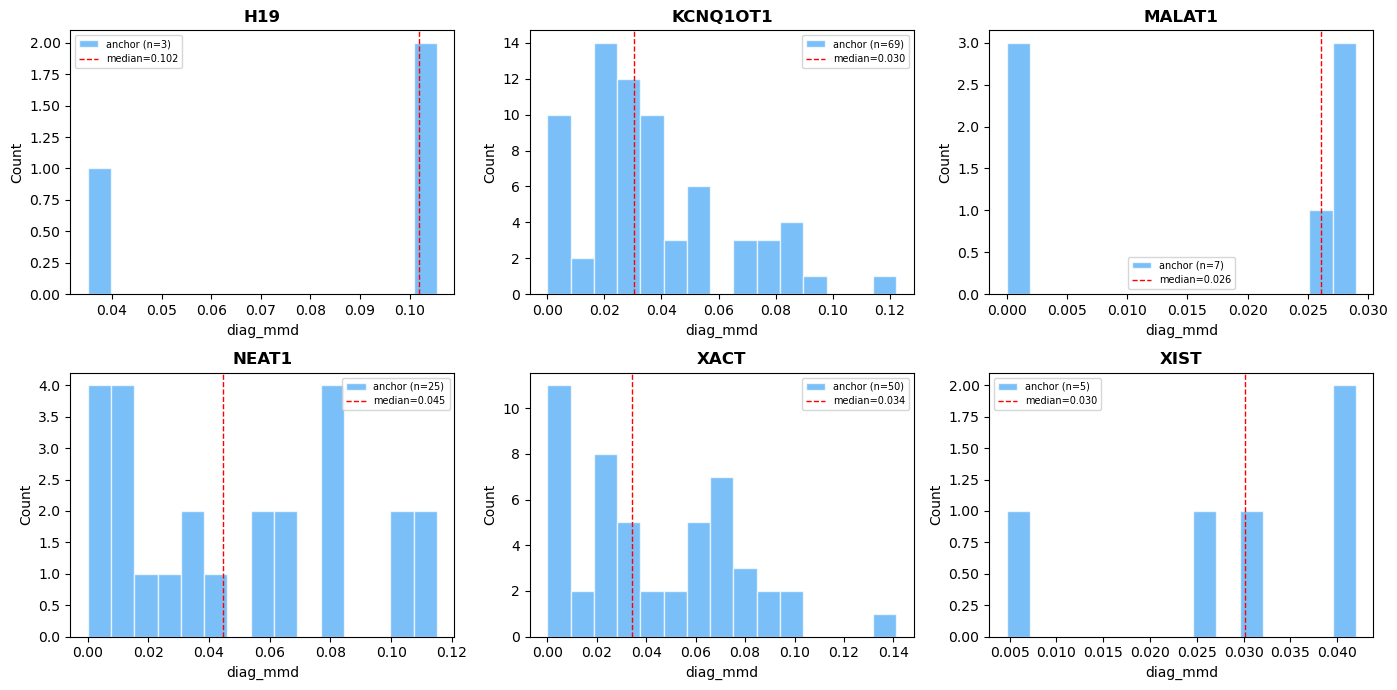

In [5]:
gene_names_sorted = sorted(ID_TO_NAME.values())
n_genes = len(gene_names_sorted)
name_to_id = {v: k for k, v in ID_TO_NAME.items()}

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, name in enumerate(gene_names_sorted):
    ax = axes[i]
    gid = name_to_id[name]
    g = sel[sel["gene_id"] == gid]

    anchors = g[g["type"] == "anchor"]["diag_mmd"]
    fills = g[g["type"] == "fill"]["diag_mmd"]

    if len(anchors) > 0:
        ax.hist(anchors, bins=15, alpha=0.7, color="#42A5F5", label=f"anchor (n={len(anchors)})",
                edgecolor="white")
    if len(fills) > 0:
        ax.hist(fills, bins=15, alpha=0.7, color="#FFA726", label=f"fill (n={len(fills)})",
                edgecolor="white")

    ax.axvline(g["diag_mmd"].median(), color="red", linestyle="--", linewidth=1,
               label=f"median={g['diag_mmd'].median():.3f}")
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("diag_mmd")
    ax.set_ylabel("Count")
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Per-gene detail

For each gene: island layout on query genome, with GENCODE exon overlap shown.


H19 (ENSG00000130600)
Query: chr7:142130877-142131825 (948 bp span)
Islands: 3 (3 anchor, 0 fill)
Transcripts in span: 23

island   type   q_start     q_end  q_len    mmd  exonic  intronic  intergenic
    Q3 anchor 142130753 142131065    312 0.1018     312         0           0
    Q5 anchor 142131425 142131593    168 0.1055     168         0           0
    Q6 anchor 142131697 142131849    152 0.0351     152         0           0


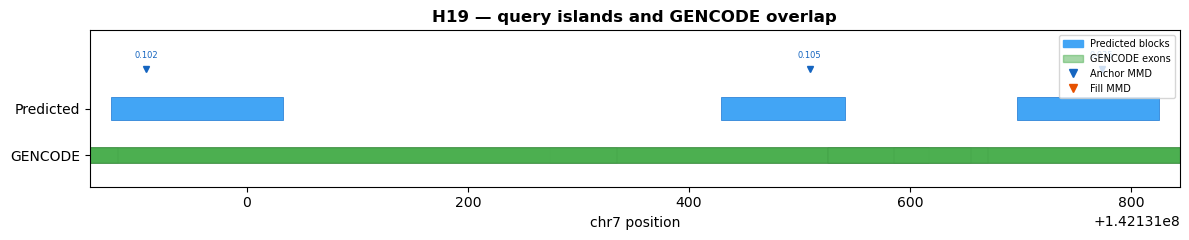


KCNQ1OT1 (ENSG00000269821)
Query: chr7:142773750-142846410 (72,660 bp span)
Islands: 69 (69 anchor, 0 fill)
Transcripts in span: 13

island   type   q_start     q_end  q_len    mmd  exonic  intronic  intergenic
    Q1 anchor 142773746 142773898    152 0.0000     152         0           0
    Q2 anchor 142779154 142779514    360 0.0240     360         0           0
    Q4 anchor 142780914 142780986     72 0.0221      72         0           0
    Q8 anchor 142804818 142804986    168 0.1223     168         0           0
    Q9 anchor 142805042 142805274    232 0.0166     232         0           0
   Q12 anchor 142806082 142806186    104 0.0559     104         0           0
   Q14 anchor 142806994 142807178    184 0.0306     184         0           0
   Q15 anchor 142807266 142807402    136 0.0045     136         0           0
   Q17 anchor 142808146 142808266    120 0.0000     120         0           0
   Q18 anchor 142808274 142808394    120 0.0309     120         0           0
   Q19 a

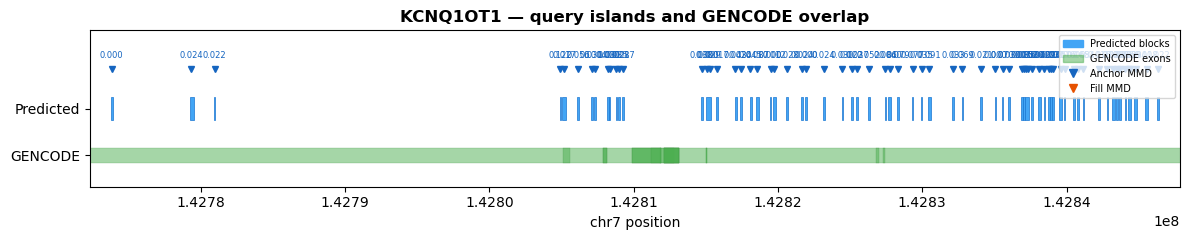


MALAT1 (ENSG00000251562)
Query: chr19:5845179-5852163 (6,984 bp span)
Islands: 7 (7 anchor, 0 fill)
Transcripts in span: 26

island   type  q_start   q_end  q_len    mmd  exonic  intronic  intergenic
    Q4 anchor  5845163 5845347    184 0.0261       0         0         184
    Q5 anchor  5845419 5845619    200 0.0285       0         0         200
    Q6 anchor  5845851 5845939     88 0.0000      88         0           0
    Q8 anchor  5847787 5847971    184 0.0290     184         0           0
   Q10 anchor  5850139 5850243    104 0.0273     104         0           0
   Q11 anchor  5850779 5850867     88 0.0000      88         0           0
   Q12 anchor  5852027 5852163    136 0.0000     136         0           0


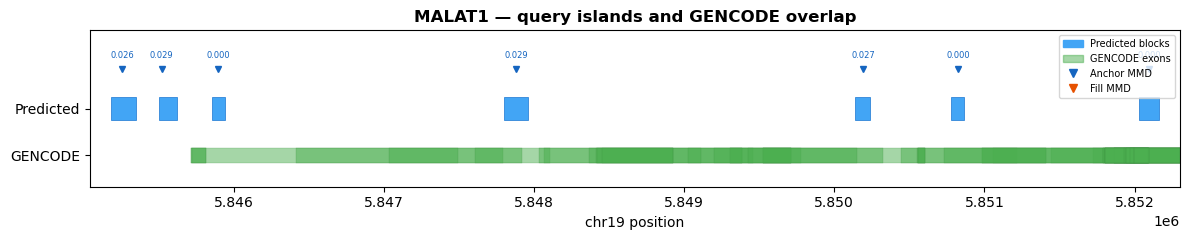


NEAT1 (ENSG00000245532)
Query: chr19:5874826-5895262 (20,436 bp span)
Islands: 25 (25 anchor, 0 fill)
Transcripts in span: 27

island   type  q_start   q_end  q_len    mmd  exonic  intronic  intergenic
    Q0 anchor  5874774 5875006    232 0.0774     232         0           0
    Q3 anchor  5875574 5875710    136 0.0446     136         0           0
    Q5 anchor  5876006 5876398    392 0.1000     392         0           0
    Q7 anchor  5876870 5877006    136 0.1081     136         0           0
    Q9 anchor  5877206 5877326    120 0.0000     120         0           0
   Q11 anchor  5877526 5877646    120 0.0000     120         0           0
   Q16 anchor  5879366 5879582    216 0.0308     216         0           0
   Q17 anchor  5879894 5880078    184 0.0820     184         0           0
   Q18 anchor  5880134 5880254    120 0.0187     120         0           0
   Q20 anchor  5880582 5880718    136 0.0632     136         0           0
   Q22 anchor  5881318 5881518    200 0.0124   

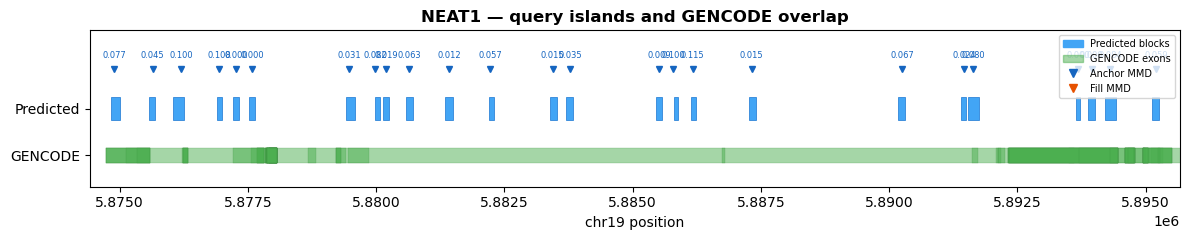


XACT (ENSG00000241743)
Query: chrX:145016916-145244152 (227,236 bp span)
Islands: 50 (50 anchor, 0 fill)
Transcripts in span: 2

island   type   q_start     q_end  q_len    mmd  exonic  intronic  intergenic
    Q2 anchor 145016880 145017016    136 0.0671       0         0         136
    Q4 anchor 145020256 145020584    328 0.0729       0         0         328
    Q5 anchor 145020576 145020744    168 0.0000       0         0         168
    Q6 anchor 145021584 145021688    104 0.0595       0         0         104
   Q13 anchor 145043072 145043192    120 0.0346       0         0         120
   Q14 anchor 145045824 145045896     72 0.0000       0         0          72
   Q17 anchor 145049584 145049704    120 0.0848       0         0         120
   Q19 anchor 145055200 145055336    136 0.0000       0         0         136
   Q26 anchor 145070720 145070840    120 0.0764       0         0         120
   Q27 anchor 145074240 145074392    152 0.0970       0         0         152
   Q28 ancho

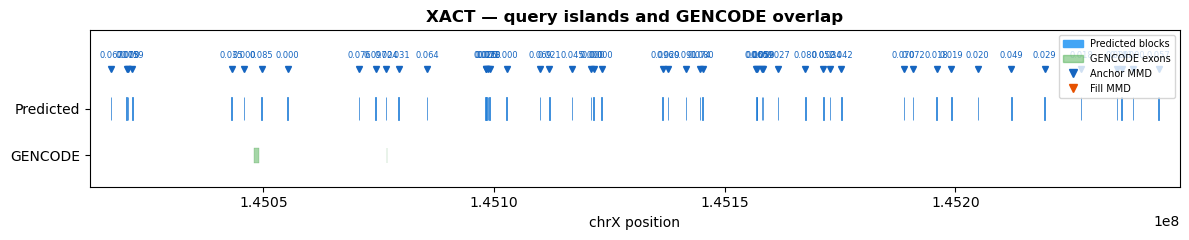


XIST (ENSG00000229807)
Query: chrX:102504796-102524052 (19,256 bp span)
Islands: 5 (5 anchor, 0 fill)
Transcripts in span: 10

island   type   q_start     q_end  q_len    mmd  exonic  intronic  intergenic
    Q0 anchor 102504784 102504904    120 0.0301     120         0           0
    Q3 anchor 102507312 102507448    136 0.0047     136         0           0
   Q14 anchor 102520896 102521032    136 0.0397     136         0           0
   Q15 anchor 102521168 102521288    120 0.0257     120         0           0
   Q16 anchor 102523776 102524056    280 0.0420     280         0           0


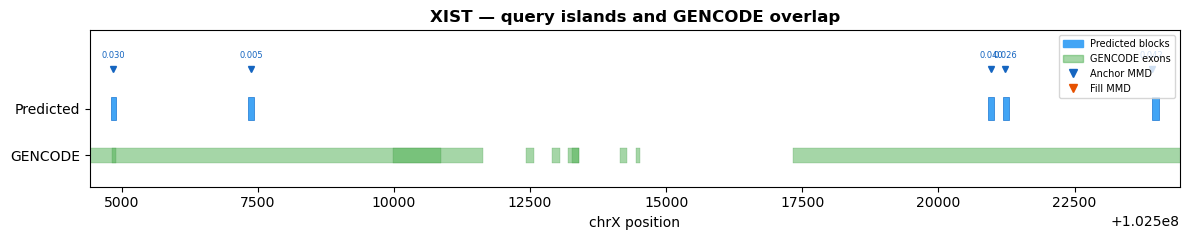

In [6]:
for name in gene_names_sorted:
    gid = name_to_id[name]
    g = sel[sel["gene_id"] == gid].sort_values("query_start")
    q_t = query_bed.get_by_id(f"{gid}_aligned")
    if q_t is None:
        print(f"\n{'='*60}\n{name} ({gid}): no query prediction\n")
        continue

    q_interval = GenomicInterval(q_t.chrom, q_t.start, q_t.end)
    hits = annotation.get_transcripts_in_interval(q_interval)

    print(f"\n{'='*60}")
    print(f"{name} ({gid.replace('U_', '')})")
    print(f"Query: {q_t.chrom}:{q_t.start}-{q_t.end} ({q_t.end - q_t.start:,} bp span)")
    print(f"Islands: {len(g)} ({(g['type']=='anchor').sum()} anchor, {(g['type']=='fill').sum()} fill)")
    print(f"Transcripts in span: {len(hits)}")

    # merge all GENCODE exon blocks and transcript spans (avoid double-counting)
    all_exon_blocks = [t.blocks for t in hits]
    all_spans = np.array([[t.start, t.end] for t in hits]) if len(hits) > 0 else np.empty((0, 2), dtype=int)

    if len(all_exon_blocks) > 0:
        merged_exons = merge_intervals(np.vstack(all_exon_blocks))
        merged_spans = merge_intervals(all_spans)
    else:
        merged_exons = np.empty((0, 2), dtype=int)
        merged_spans = np.empty((0, 2), dtype=int)

    # per-island table with exonic / intronic / intergenic breakdown
    island_rows = []
    for _, isl in g.iterrows():
        isl_arr = np.array([[isl["query_start"], isl["query_end"]]])
        isl_len = isl["query_len"]

        exon_isect = intersect_intervals(isl_arr, merged_exons)
        exonic_bp = int(np.sum(exon_isect[:, 1] - exon_isect[:, 0])) if len(exon_isect) > 0 else 0

        span_isect = intersect_intervals(isl_arr, merged_spans)
        in_transcript_bp = int(np.sum(span_isect[:, 1] - span_isect[:, 0])) if len(span_isect) > 0 else 0

        intronic_bp = in_transcript_bp - exonic_bp
        intergenic_bp = isl_len - in_transcript_bp

        island_rows.append({
            "island": isl["query_island"],
            "type": isl["type"],
            "q_start": isl["query_start"],
            "q_end": isl["query_end"],
            "q_len": isl_len,
            "mmd": f"{isl['diag_mmd']:.4f}",
            "exonic": exonic_bp,
            "intronic": intronic_bp,
            "intergenic": intergenic_bp,
        })
    isl_df = pd.DataFrame(island_rows)
    print(f"\n{isl_df.to_string(index=False)}")

    # plot: genomic layout
    fig, ax = plt.subplots(figsize=(12, 2.5))
    span_start = q_t.start
    span_end = q_t.end

    # predicted blocks (from BED12)
    for block_s, block_e in q_t.blocks:
        ax.barh(1.0, block_e - block_s, left=block_s, height=0.3,
                color="#42A5F5", edgecolor="#1976D2", linewidth=0.5)

    # annotation exons in the region
    anno_y = 0.4
    for t in hits:
        for block_s, block_e in t.blocks:
            if block_e > span_start and block_s < span_end:
                ax.barh(anno_y, block_e - block_s, left=block_s, height=0.2,
                        color="#4CAF50", alpha=0.5, edgecolor="#388E3C", linewidth=0.3)

    # island MMD annotations
    for _, isl in g.iterrows():
        mid = (isl["query_start"] + isl["query_end"]) / 2
        color = "#1565C0" if isl["type"] == "anchor" else "#E65100"
        ax.plot(mid, 1.5, marker="v", color=color, markersize=5)
        ax.text(mid, 1.65, f'{isl["diag_mmd"]:.3f}', ha="center", fontsize=6, color=color)

    ax.set_xlim(span_start - (span_end - span_start) * 0.02,
                span_end + (span_end - span_start) * 0.02)
    ax.set_ylim(0, 2.0)
    ax.set_yticks([0.4, 1.0])
    ax.set_yticklabels(["GENCODE", "Predicted"])
    ax.set_xlabel(f"{q_t.chrom} position")
    ax.set_title(f"{name} — query islands and GENCODE overlap", fontweight="bold")

    legend_elements = [
        mpatches.Patch(color="#42A5F5", label="Predicted blocks"),
        mpatches.Patch(color="#4CAF50", alpha=0.5, label="GENCODE exons"),
        plt.Line2D([0], [0], marker="v", color="#1565C0", linestyle="None", label="Anchor MMD"),
        plt.Line2D([0], [0], marker="v", color="#E65100", linestyle="None", label="Fill MMD"),
    ]
    ax.legend(handles=legend_elements, fontsize=7, loc="upper right")

    plt.tight_layout()
    plt.show()